In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import vtk

In [3]:
pheno_triax = np.load('./data/pheno_triax.npy')
dislo_triax = np.load('./data/dislo_triax.npy')

In [ ]:
pheno_triax_grid = pv.ImageData()
dislo_triax_grid = pv.ImageData()

pheno_triax_grid.dimensions = (pheno_triax.shape[0]+1, pheno_triax.shape[1]+1, pheno_triax.shape[2]+1)
dislo_triax_grid.dimensions = (dislo_triax.shape[0]+1, dislo_triax.shape[1]+1, dislo_triax.shape[2]+1)

pheno_triax_grid.cell_data["triax_values"] = pheno_triax.flatten(order = 'F')
dislo_triax_grid.cell_data["triax_values"] = dislo_triax.flatten(order = 'F')

In [4]:
dislo_triax_flat = dislo_triax.flatten()
pheno_triax_flat = pheno_triax.flatten()
print(dislo_triax_flat.max(), pheno_triax_flat.max())

for i in range(len(pheno_triax_flat)):
    if (dislo_triax_flat[i] > 0 and pheno_triax_flat[i] > 0) or (dislo_triax_flat[i] < 0 and pheno_triax_flat[i] < 0) :
        pheno_triax_flat[i] = np.nan
        dislo_triax_flat[i] = np.nan

triax_largest_diff_flat = np.empty(len(pheno_triax_flat))
triax_largest_diff_flat[:] = np.nan

for i in range(len(pheno_triax_flat)):
    if not np.isnan(pheno_triax_flat[i]):
        if pheno_triax_flat[i] > dislo_triax_flat[i]:
            triax_largest_diff_flat[i] = pheno_triax_flat[i] - dislo_triax_flat[i]
        elif dislo_triax_flat[i] > pheno_triax_flat[i]:
            triax_largest_diff_flat[i] = dislo_triax_flat[i] - pheno_triax_flat[i]
print(triax_largest_diff_flat)

4.200635413902881 3.079690866754879
[nan nan nan ... nan nan nan]


In [5]:
triax_largest_diff_opp = triax_largest_diff_flat.reshape([128,128,128])

In [6]:
type(triax_largest_diff_opp)

numpy.ndarray

/var/folders/wf/w5dwy83s0fx0s7c253xdmr1m0000gp/T/ipykernel_19550/3578165069.py:17: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  triax_diff_pl.show()


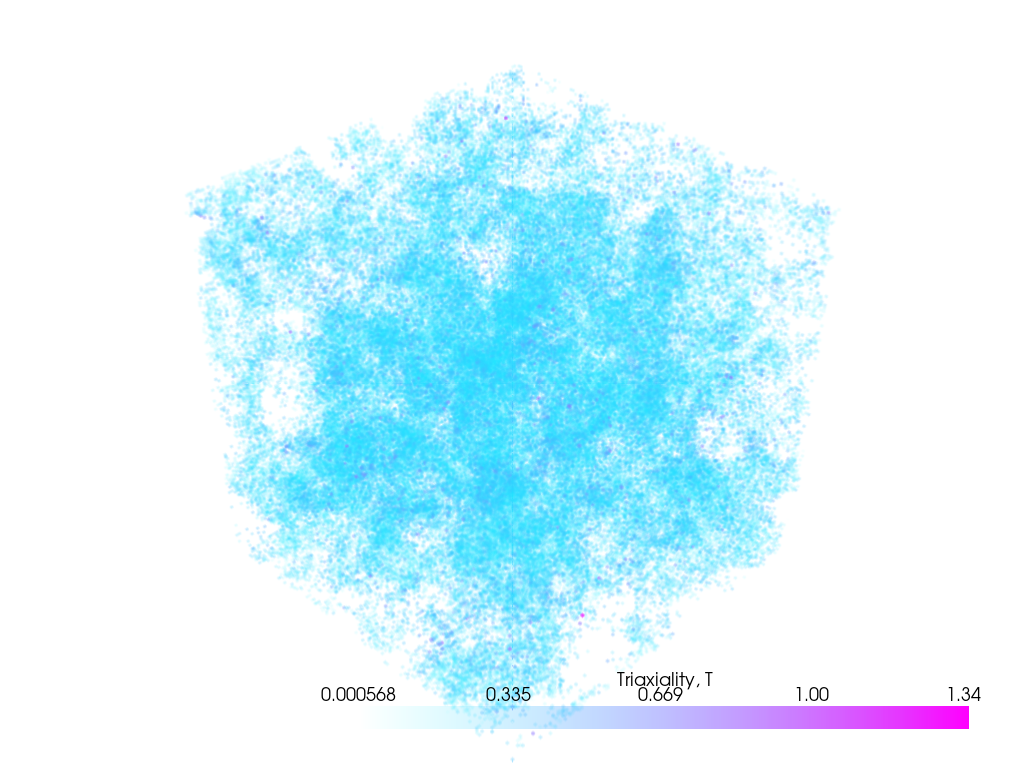

In [9]:
triax_largest_diffs_grid = pv.ImageData()
triax_largest_diffs_grid.dimensions = (triax_largest_diff_opp.shape[0]+1, triax_largest_diff_opp.shape[1]+1, triax_largest_diff_opp.shape[2]+1)
triax_largest_diffs_grid.cell_data["triax_values"] = triax_largest_diff_opp.flatten(order = 'F')

#triax_largest_diffs_grid.save("triax_comp_grid.vti")

triax_largest_diffs_grid_no_nan = triax_largest_diffs_grid.threshold([-np.inf, np.inf], scalars="triax_values")

triax_diff_pl = pv.Plotter()
triax_diff_pl.add_volume(
    triax_largest_diffs_grid_no_nan,
    scalars = 'triax_values',
    cmap = 'cool',
    opacity = 'linear',
    scalar_bar_args={"title": r"Triaxiality, T"})

triax_diff_pl.show()

# Saving stress triaxiality output as .vti file

In [ ]:
volume = VTKImage.read("../../geom_128x128x128.vti")